## Exploratory Data Analysis (EDA)


#### LIBRARIES

In [4]:
import sys
from pathlib import Path

from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu, shapiro
from src.preprocessing import preprocess_data

Loading the data...  
Variables with more than 50% missing values were identified and excluded from further analysis. 

In [5]:
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

%matplotlib inline
sns.set_theme(style="whitegrid")

#Load and preprocess
file_path = project_root / "data" / "RA_Dataset.xlsx"
df_all = preprocess_data(file_path)

# Drop rows where target variable is missing (the last visit of each patient)
df_cleaned = df_all.dropna(subset=["flare_next_visit"]).copy()
df_cleaned['flare_next_visit'] = df_cleaned['flare_next_visit'].astype(int)

Dropping columns with > 50% missing values: smoking, tjc_28, sjc_28, vas


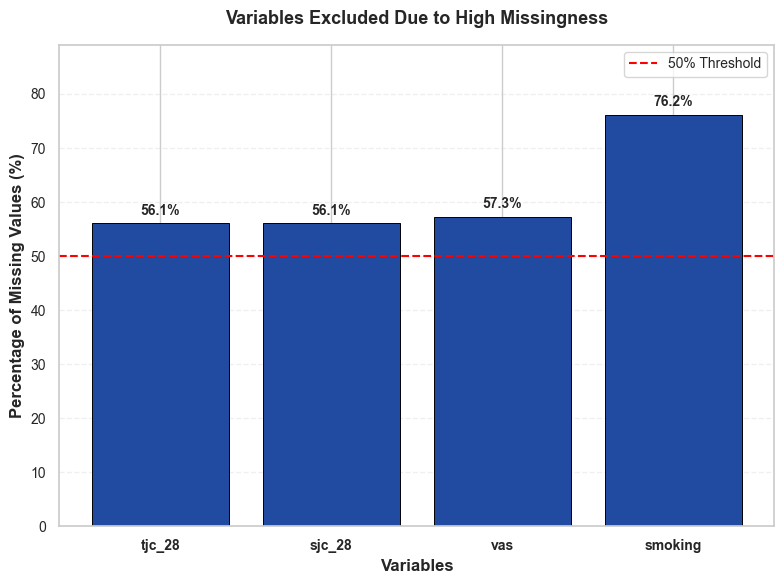

In [6]:
from src.preprocessing import handle_categorical_missing, load_data

#Load raw data to visualize baseline missingness
df_raw = load_data(file_path)
handle_categorical_missing(df_raw)

#Identify variables exceeding the 50% missing threshold
missing_percent = (df_raw.isnull().mean() * 100).sort_values(ascending=True)
high_missing = missing_percent[missing_percent > 50]

#Plot
plt.figure(figsize=(8, 6))
bars = plt.bar(high_missing.index, high_missing.values, color="#204BA1", edgecolor='black', linewidth=0.7)
# Add percentage labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.axhline(50, color='red', linestyle='--', linewidth=1.5, label='50% Threshold')
plt.xlabel('Variables', fontsize=12, fontweight='bold')
plt.ylabel('Percentage of Missing Values (%)', fontsize=12, fontweight='bold')
plt.title('Variables Excluded Due to High Missingness', fontsize=13, fontweight='bold', pad=15)
plt.xticks(ha='center', fontsize=10, fontweight='bold')
plt.yticks(fontsize=10)
plt.ylim(0, max(high_missing.values) * 1.17)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

#### Dataset Overview

In [7]:
df_cleaned.shape

(393, 49)

In [8]:
df_cleaned.head(10)

,patient_id,gender,year_of_diagnosis,rf_status,anti_ccp_status,comorbidities,visit_date,visit_type,crp,crp_upper_limit,...,comorb_gastrointestinal_hepatic,comorb_malignancy,comorb_musculoskeletal,comorb_neurologic_psychiatric,comorb_autoimmune_other,comorbidity_count,csdmard_use,b_ts_dmard_use,steroid_use,treatment_count
0,RA001,1,1997,0,0,"depression,hypothyroidism",2017-12-18,Baseline,0.40,0.5,...,0,0,0,1,0,2,1,1,0,3
1,RA001,1,1997,0,0,"depression,hypothyroidism",2018-03-20,Follow-up,0.40,0.5,...,0,0,0,1,0,2,1,0,0,2
2,RA001,1,1997,0,0,"depression,hypothyroidism",2018-09-25,Follow-up,0.40,0.5,...,0,0,0,1,0,2,0,1,0,1
4,RA002,1,1999,0,0,,2023-10-27,Baseline,0.02,0.5,...,0,0,0,0,0,0,1,1,0,3
5,RA002,1,1999,0,0,,2024-01-30,Follow-up,0.07,0.5,...,0,0,0,0,0,0,1,1,0,2
6,RA002,1,1999,0,0,,2024-04-23,Follow-up,1.90,5.0,...,0,0,0,0,0,0,1,1,0,2
7,RA002,1,1999,0,0,,2024-09-17,Follow-up,0.10,0.5,...,0,0,0,0,0,0,1,1,0,2
9,RA003,0,2005,1,1,transient ischemic attack,2023-09-01,Baseline,0.46,0.5,...,0,0,0,0,0,1,0,0,0,0
11,RA004,0,2016,1,1,chronic obstructive pulmonary disease,2016-05-16,Baseline,NaN,NaN,...,0,0,0,0,0,1,1,0,1,3
12,RA004,0,2016,1,1,chronic obstructive pulmonary disease,2016-09-20,Follow-up,6.60,5.0,...,0,0,0,0,0,1,1,0,1,2


In [9]:
df_cleaned.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
Index: 393 entries, 0 to 497
Data columns (total 49 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   patient_id                       393 non-null    str           
 1   gender                           393 non-null    Int64         
 2   year_of_diagnosis                391 non-null    Int64         
 3   rf_status                        390 non-null    Int64         
 4   anti_ccp_status                  390 non-null    Int64         
 5   comorbidities                    393 non-null    str           
 6   visit_date                       393 non-null    datetime64[us]
 7   visit_type                       393 non-null    str           
 8   crp                              326 non-null    float64       
 9   crp_upper_limit                  326 non-null    float64       
 10  esr                              361 non-null    float64       
 11  das28_sco

#### Missingness Analysis

In [22]:
#complete patients without NaN values
patient_complete = df_cleaned.groupby("patient_id").apply(lambda x: x.notna().all().all())
complete_patients = patient_complete[patient_complete].index.tolist()
print("Number of patients with complete data:", len(complete_patients))

Number of patients with complete data: 22


                   missing_count  missing_percentage
das28_score                  145                36.9
das28_change                 134                34.1
crp_upper_limit               67                17.0
crp                           67                17.0
crp_normalized                67                17.0
esr                           32                 8.1
inflammation_flag             22                 5.6
rf_status                      3                 0.8
anti_ccp_status                3                 0.8
year_of_diagnosis              2                 0.5
disease_duration               2                 0.5


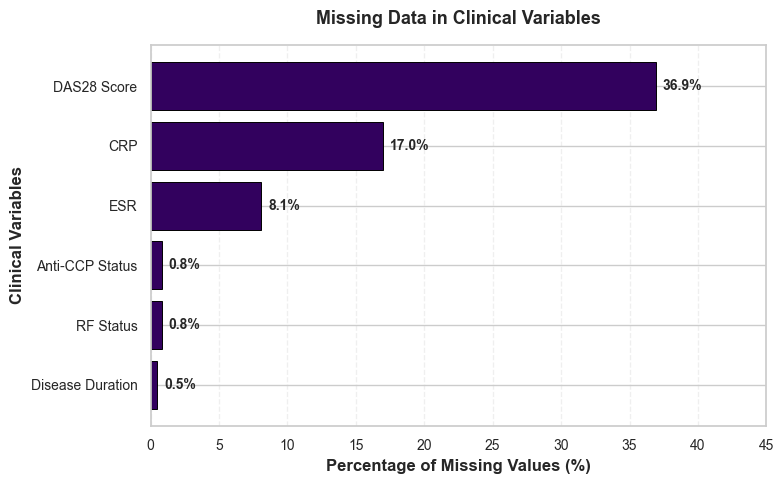

In [23]:
missing_count = df_cleaned.isnull().sum()
missing_percentage = (df_cleaned.isnull().mean() * 100).round(1)

#Summary Table
missing_table = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percentage': missing_percentage
    }).sort_values(by='missing_percentage', ascending=False)

print(missing_table[missing_table['missing_percentage'] > 0])


missing_data_variables = [
    'rf_status',
    'anti_ccp_status',
    'crp_normalized',
    'esr',
    'das28_score',
    'disease_duration'
]

labels={
    'rf_status': 'RF Status',
    'anti_ccp_status': 'Anti-CCP Status',
    'crp_normalized': 'CRP',
    'esr': 'ESR',
    'das28_score': 'DAS28 Score',
    'disease_duration': 'Disease Duration'
}
# Barplot of missing percentages
plt.figure(figsize=(8, 5))
missing_plot = (missing_table.loc[missing_table.index.isin(missing_data_variables)]
                .sort_values(by='missing_percentage', ascending=True))
bars = plt.barh(missing_plot.index, missing_plot['missing_percentage'], color="#32015EFF", edgecolor='black', linewidth=0.7)

sorted_raw_indices = missing_plot.index
y_labels = [labels.get(var, var) for var in sorted_raw_indices]

plt.yticks(range(len(sorted_raw_indices)), y_labels, fontsize=10)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}%', va='center', fontweight='bold', fontsize=10)
plt.title('Missing Data in Clinical Variables', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Percentage of Missing Values (%)', fontsize=12, fontweight='bold')
plt.ylabel('Clinical Variables', fontsize=12, fontweight='bold')
plt.gca().tick_params(axis='x', labelsize=10)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.xlim(0, 45)
plt.tight_layout()
plt.show()

In [24]:
#CRP missingness percentages (flare vs no flare)
crp_percent = pd.crosstab(df_cleaned["crp_missing"], df_cleaned["flare_next_visit"], normalize="index", 
            rownames=["CRP missing"], colnames=["Flare next visit"]).round(2)
display(crp_percent)
#Chi-Square Test for CRP Missingness
contingency_table_crp = pd.crosstab(df_cleaned['crp_missing'], df_cleaned['flare_next_visit'])
chi2_crp, p_crp, dof_crp, expected_crp = chi2_contingency(contingency_table_crp)
print(f"Chi-Square Test for CRP Missingness:")
print(f"Chi2 Statistic: {chi2_crp:.4f}, p-value: {p_crp:.4f}")
print("Expected Frequencies:")
print(expected_crp)

#ESR missingness percentages (flare vs no flare)
esr_percent = pd.crosstab(df_cleaned["esr_missing"], df_cleaned["flare_next_visit"], normalize="index", 
            rownames=["ESR missing"], colnames=["Flare next visit"]).round(2)
display(esr_percent)
#Chi-Square Test for ESR Missingness
contingency_table_esr = pd.crosstab(df_cleaned['esr_missing'], df_cleaned['flare_next_visit'])
chi2_esr, p_esr, dof_esr, expected_esr = chi2_contingency(contingency_table_esr)
print(f"\nChi-Square Test for ESR Missingness:")
print(f"Chi2 Statistic: {chi2_esr:.4f}, p-value: {p_esr:.4f}")
print("Expected Frequencies:")
print(expected_esr)

#DAS28 missingness percentages (flare vs no flare)
df_cleaned['das28_missing'] = df_cleaned['das28_change'].isnull().astype(int)
das28_percent = pd.crosstab(df_cleaned["das28_missing"], df_cleaned["flare_next_visit"], normalize="index", 
            rownames=["DAS28 Missing"], colnames=["Flare next visit"]).round(2)
display(das28_percent)
#Chi-Square Test for DAS28 Missingness
contingency_table_das28 = pd.crosstab(df_cleaned['das28_missing'], df_cleaned['flare_next_visit'])
chi2_das28, p_das28, dof_das28, expected_das28 = chi2_contingency(contingency_table_das28)
print(f"\nChi-Square Test for DAS28 Missingness:")
print(f"Chi2 Statistic: {chi2_das28:.4f}, p-value: {p_das28:.4f}")
print("Expected Frequencies:")
print(expected_das28)

Flare next visit,0,1
CRP missing,,
0,0.68,0.32
1,0.63,0.37


Chi-Square Test for CRP Missingness:
Chi2 Statistic: 0.4440, p-value: 0.5052
Expected Frequencies:
[[218.16284987 107.83715013]
 [ 44.83715013  22.16284987]]


Flare next visit,0,1
ESR missing,,
0,0.66,0.34
1,0.72,0.28



Chi-Square Test for ESR Missingness:
Chi2 Statistic: 0.1810, p-value: 0.6705
Expected Frequencies:
[[241.58524173 119.41475827]
 [ 21.41475827  10.58524173]]


Flare next visit,0,1
DAS28 Missing,,
0,0.66,0.34
1,0.68,0.32



Chi-Square Test for DAS28 Missingness:
Chi2 Statistic: 0.0349, p-value: 0.8519
Expected Frequencies:
[[173.32569975  85.67430025]
 [ 89.67430025  44.32569975]]


To evaluate whether missing clinical values introduce informative bias (Missing Not At Random), cross-tabulation and $\chi^2$ tests of independence were performed between feature missingness indicators and subsequent flare status (flare_next_visit).  Across all three key disease-activity markers (CRP, ESR, and DAS28 score), missingness is not significantly correlated with whether a patient experiences a flare at the subsequent visit (all $p > 0.50$, percentages in cross tabulation did not differ significantly).

#### Target Analysis

In [25]:
# Percentages of target variable
df_cleaned["flare_next_visit"].value_counts(normalize=True, dropna=False) * 100

flare_next_visit
0    66.92112
1    33.07888
Name: proportion, dtype: float64

The target variable exhibits moderate class imbalance, with 67% non-flare visits ($0$) and 33% flare visits ($1$)

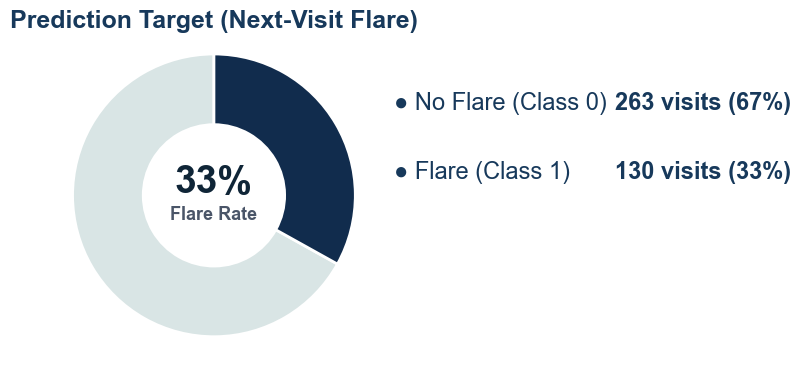

In [ ]:
flare_counts = df_cleaned['flare_next_visit'].value_counts().sort_index()
flare_labels = {0: 'No Flare (Class 0)', 1: 'Physician Flare (Class 1)'}
flare_sizes = [flare_counts.get(0, 0), flare_counts.get(1, 0)]
flare_pct = [(value / sum(flare_sizes)) * 100 for value in flare_sizes]

fig, ax = plt.subplots(figsize=(8,6), dpi=100)
wedges, _ = ax.pie(
    flare_sizes,
    startangle=90,
    counterclock=True,
    colors=['#D9E5E5', '#112C4D'],
    labels=None,
    wedgeprops={'width': 0.55, 'edgecolor': 'white', 'linewidth': 2},
    radius=1.1
)

ax.set_aspect('equal')
ax.set_title('Prediction Target (Next-Visit Flare)', fontsize=18, fontweight='bold', color='#17395B', pad=5)
ax.axis('off')
ax.text(0, 0.10, f'{flare_pct[1]:.0f}%', ha='center', va='center', fontsize=28, fontweight='bold', color='#0F2537')
ax.text(0, -0.15, 'Flare Rate', ha='center', va='center', fontsize=13, fontweight='bold', color='#4A5568')
ax.text(1.40, 0.72, '● No Flare (Class 0)', ha='left', va='center', fontsize=17, color='#17395B')
ax.text(3.12, 0.72, f'{flare_sizes[0]} visits ({flare_pct[0]:.0f}%)', ha='left', va='center', fontsize=17, fontweight='bold', color='#17395B')
ax.text(1.40, 0.18, '● Flare (Class 1)', ha='left', va='center', fontsize=17, color='#17395B')
ax.text(3.12, 0.18, f'{flare_sizes[1]} visits ({flare_pct[1]:.0f}%)', ha='left', va='center', fontsize=17, fontweight='bold', color='#17395B')
plt.tight_layout()
plt.show()

Baseline characteristics of the dataset

In [38]:
#One row per patient: first recorded visit
baseline = df_all.sort_values(["patient_id", "visit_date"]) \
                     .groupby("patient_id", as_index=False) \
                     .head(1)

# Mean ± SD
def mean_sd(series):
    return f"{series.mean():.1f} ± {series.std():.1f}"

# Median (IQR)
def median_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    return f"{series.median():.2f} ({q1:.2f}–{q3:.2f})"

def n_percent(series, value=1):
    n = (series == value).sum()
    total = series.notna().sum()
    return f"{n} ({100*n/total:.1f}%)"

visits_per_patient = df_all.groupby("patient_id").size()

baseline_stats = {
    'Age at first visit': mean_sd(baseline["age_at_visit"]),
    'Disease duration': median_iqr(baseline["disease_duration"]),
    'DAS28 score': mean_sd(baseline["das28_score"].dropna()),
    'CRP normalized': median_iqr(baseline["crp_normalized"].dropna()),
    'ESR (mm/hr)': median_iqr(baseline["esr"].dropna()),
    'Female': n_percent(baseline["gender"], 1),
    'Male': n_percent(baseline["gender"], 0),
    'RF positive': n_percent(baseline["rf_status"], 1),
    'Anti-CCP positive': n_percent(baseline["anti_ccp_status"], 1),
    'Patients with ≥1 comorbidity': n_percent(baseline["comorbidity_count"] >= 1, True),
    'Visits per patient': median_iqr(visits_per_patient)
}

baseline_characteristics = pd.DataFrame(list(baseline_stats.items()), columns=['Characteristic', 'Value'])
baseline_characteristics

,Characteristic,Value
0,Age at first visit,60.5 ± 11.5
1,Disease duration,4.00 (0.00–14.00)
2,DAS28 score,3.9 ± 1.3
3,CRP normalized,0.92 (0.41–2.12)
4,ESR (mm/hr),25.00 (16.00–37.00)
5,Female,83 (78.3%)
6,Male,23 (21.7%)
7,RF positive,54 (51.9%)
8,Anti-CCP positive,64 (61.5%)
9,Patients with ≥1 comorbidity,84 (79.2%)


Time-varying variables

In [41]:
time_varying_variables = {
    'Days since last visit': median_iqr(df_cleaned["days_since_last_visit"]),
    'DAS28 score': mean_sd(df_cleaned["das28_score"]),
    'Das28 change': mean_sd(df_cleaned["das28_change"]),
    'CRP normalized': median_iqr(df_cleaned["crp_normalized"]),
    'ESR (mm/hr)': median_iqr(df_cleaned["esr"]),
    'MTX use': n_percent(df_cleaned["mtx_use"], 1),
    'csDMARD use': n_percent(df_cleaned["csdmard_use"], 1),
    'b_ts_DMARD use': n_percent(df_cleaned["b_ts_dmard_use"], 1),
    'Corticosteroid use': n_percent(df_cleaned["steroid_use"], 1),
    'Treatment count': median_iqr(df_cleaned["treatment_count"]),
    'Previous flare': n_percent(df_cleaned["previous_flare"], 1)

}
time_varying_characteristics = pd.DataFrame(list(time_varying_variables.items()), columns=['Characteristic', 'Value'])
time_varying_characteristics

,Characteristic,Value
0,Days since last visit,127.00 (0.00–238.00)
1,DAS28 score,3.4 ± 1.2
2,Das28 change,-0.1 ± 0.9
3,CRP normalized,0.63 (0.26–1.60)
4,ESR (mm/hr),20.00 (11.00–35.00)
5,MTX use,219 (55.7%)
6,csDMARD use,223 (56.7%)
7,b_ts_DMARD use,160 (40.7%)
8,Corticosteroid use,148 (37.7%)
9,Treatment count,2.00 (1.00–3.00)


#### Visits per Petient

count    106.000000
mean       4.707547
std        2.559639
min        2.000000
25%        3.000000
50%        4.000000
75%        6.000000
max       16.000000
dtype: float64


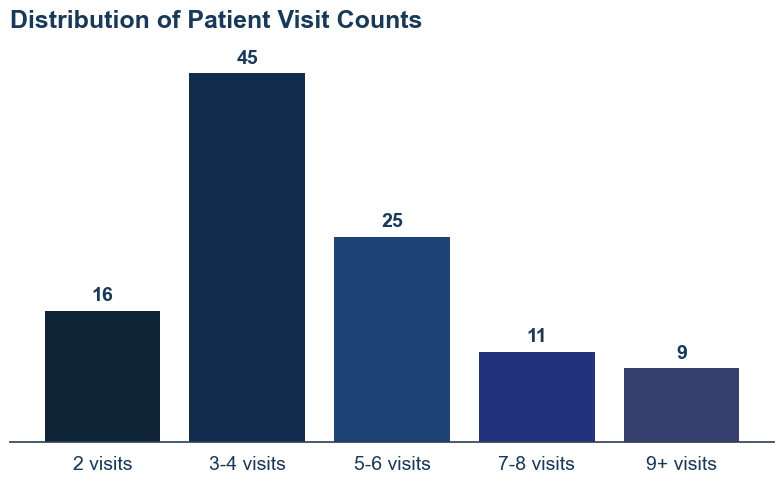

In [44]:
print(visits_per_patient.describe())
visit_bins = pd.cut(
    visits_per_patient,
    bins=[2, 3, 5, 7, 9, np.inf],
    labels=['2 visits', '3-4 visits', '5-6 visits', '7-8 visits', '9+ visits'],
    right=False,
)

visit_counts = visit_bins.value_counts().reindex(
    ['2 visits', '3-4 visits', '5-6 visits', '7-8 visits', '9+ visits'],
    fill_value=0
)

colors = ['#0F2537', "#112C4D", "#1F4277", "#23327D", "#37406E"]

fig, ax = plt.subplots(figsize=(8, 5), dpi=100)
bars = ax.bar(visit_counts.index, visit_counts.values, color=colors, edgecolor='none', width=0.8)
ax.set_title('Distribution of Patient Visit Counts', fontsize=18, fontweight='bold', color='#17395B', pad=20, loc='left')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_axisbelow(True)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#2C3E50')
ax.spines['bottom'].set_linewidth(1.2)
ax.tick_params(axis='x', labelsize=14, colors='#17395B')
ax.tick_params(axis='y', left=False, labelleft=False)

for bar, value in zip(bars, visit_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.8,
        str(value),
        ha='center', va='bottom', fontsize=14, color='#17395B', fontweight='bold'
    )
plt.tight_layout()
plt.show()

### Univariate Analysis

#### Continuous variables

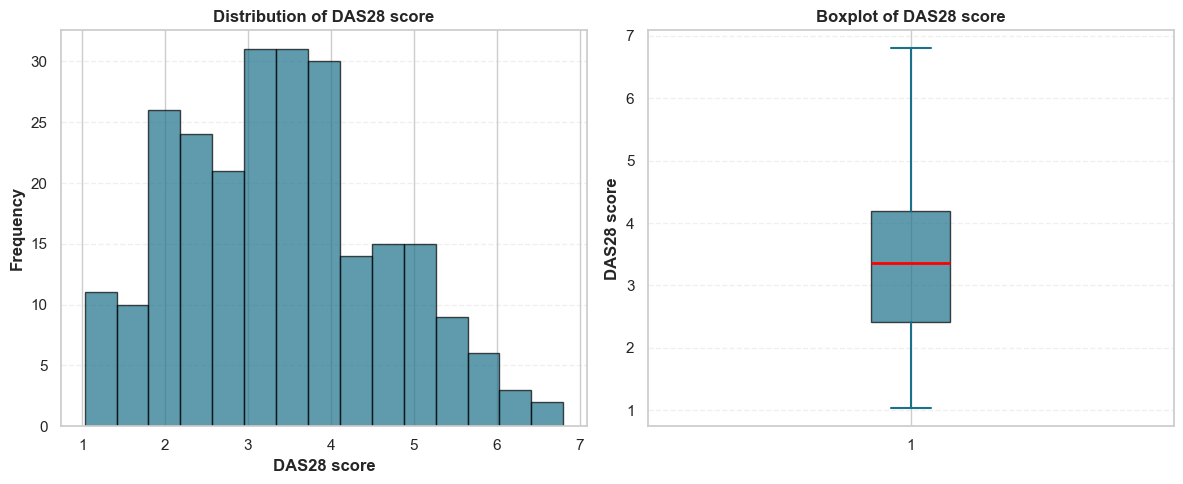

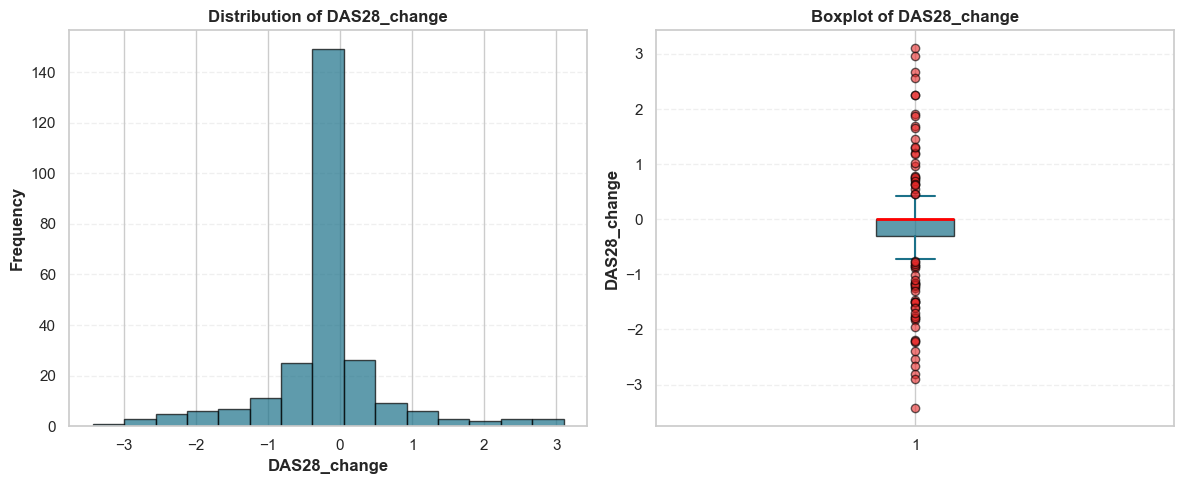

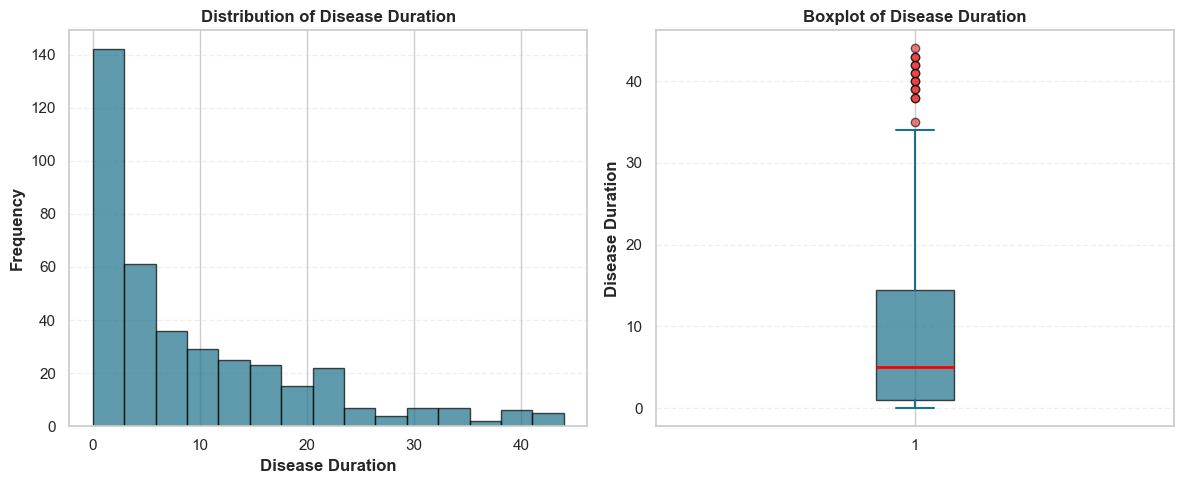

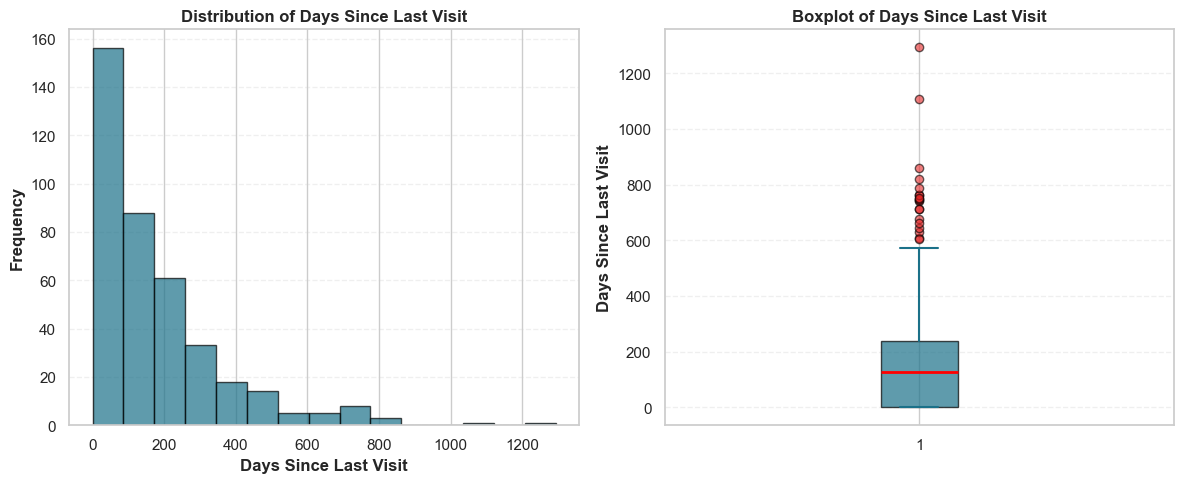

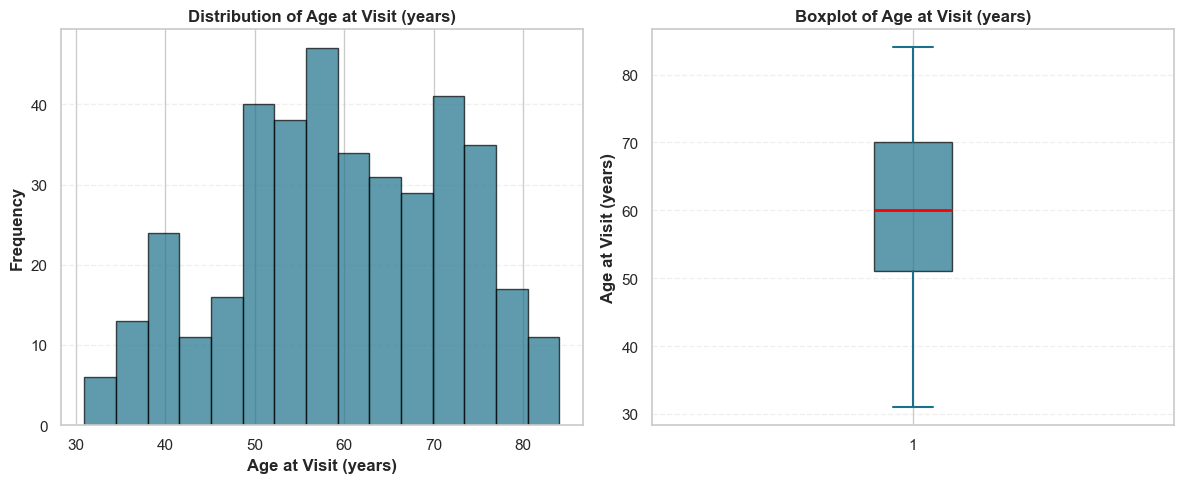

In [45]:
continuous_variables = {
    'DAS28 score': df_cleaned['das28_score'],
    'DAS28_change': df_cleaned['das28_change'],
    'Disease Duration': df_cleaned['disease_duration'],
    'Days Since Last Visit': df_cleaned['days_since_last_visit'],
    'Age at Visit (years)': df_cleaned['age_at_visit'], 
    
}

for col_name, col_data in continuous_variables.items():
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    #Histogram
    axes[0].hist(
        col_data.dropna(),
        bins=15,
        color="#1B7189",
        edgecolor='black',
        alpha=0.7
    )
    axes[0].set_title(f'Distribution of {col_name}', fontweight='bold', fontsize=12)
    axes[0].set_xlabel(col_name, fontweight='bold')
    axes[0].set_ylabel('Frequency', fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3, linestyle='--')
    
    #Boxplot
    bp = axes[1].boxplot(col_data.dropna(), vert=True, patch_artist=True)
    
    #Color the box
    bp['boxes'][0].set_facecolor('#1B7189')
    bp['boxes'][0].set_alpha(0.7)
    
    #Style whiskers, caps, and medians
    for whisker in bp['whiskers']:
        whisker.set(linewidth=1.5, color='#1B7189')
    for cap in bp['caps']:
        cap.set(linewidth=1.5, color='#1B7189')
    for median in bp['medians']:
        median.set(linewidth=2, color='red')
    
    #Style outliers
    for flier in bp['fliers']:
        flier.set(marker='o', markerfacecolor='#e72828', markersize=6, alpha=0.6)
    axes[1].set_title(f'Boxplot of {col_name}', fontweight='bold', fontsize=12)
    axes[1].set_ylabel(col_name, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()

Biomarkers such as CRP and ESR, showed high skewness, therefore log1p transformation was applied.

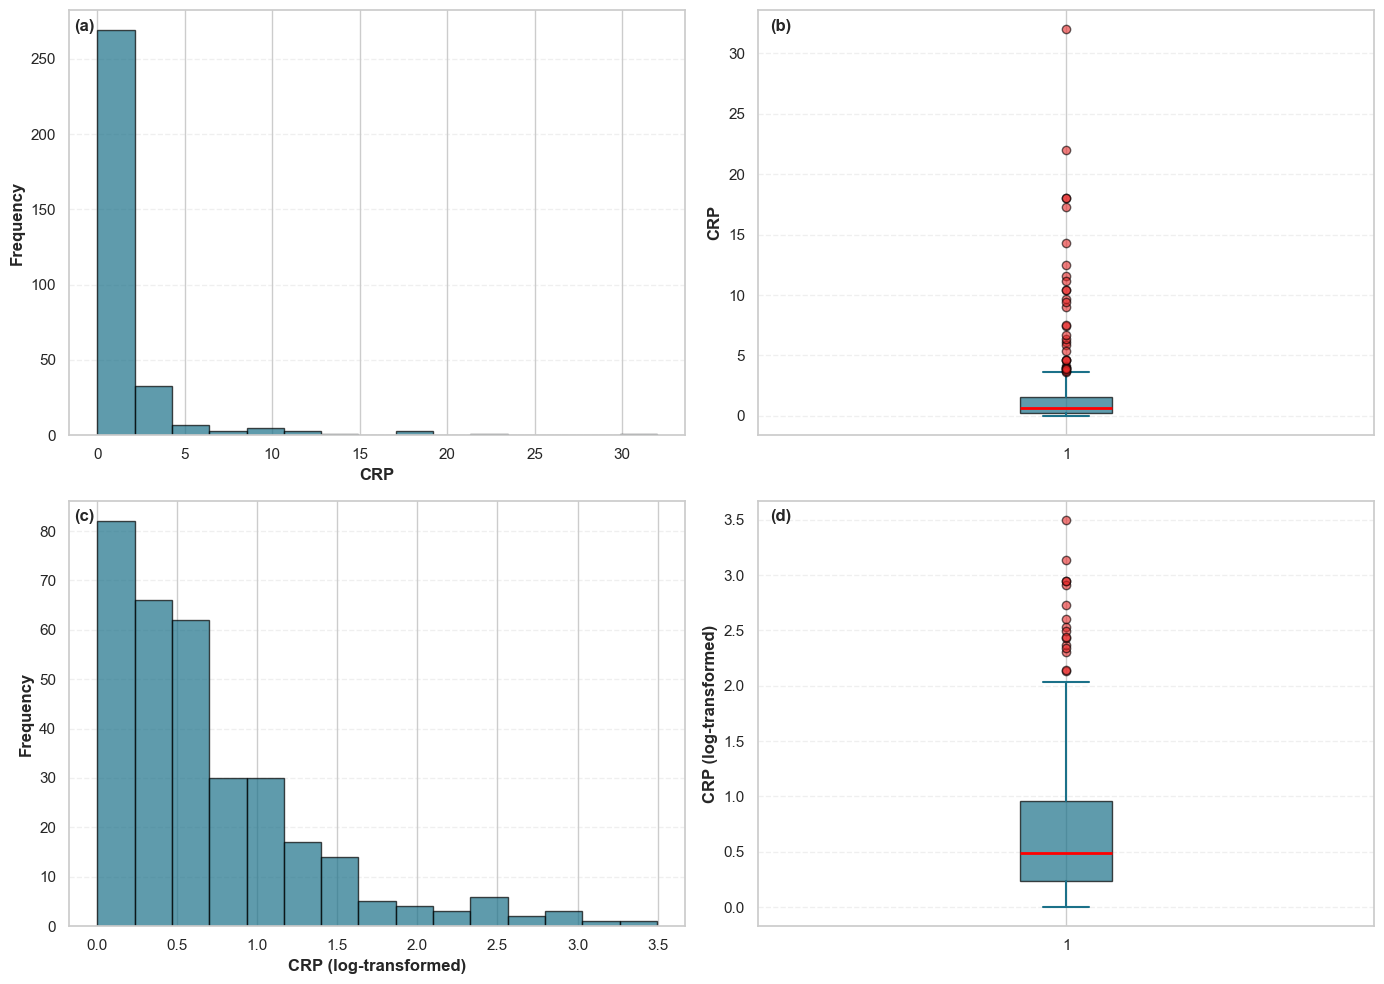

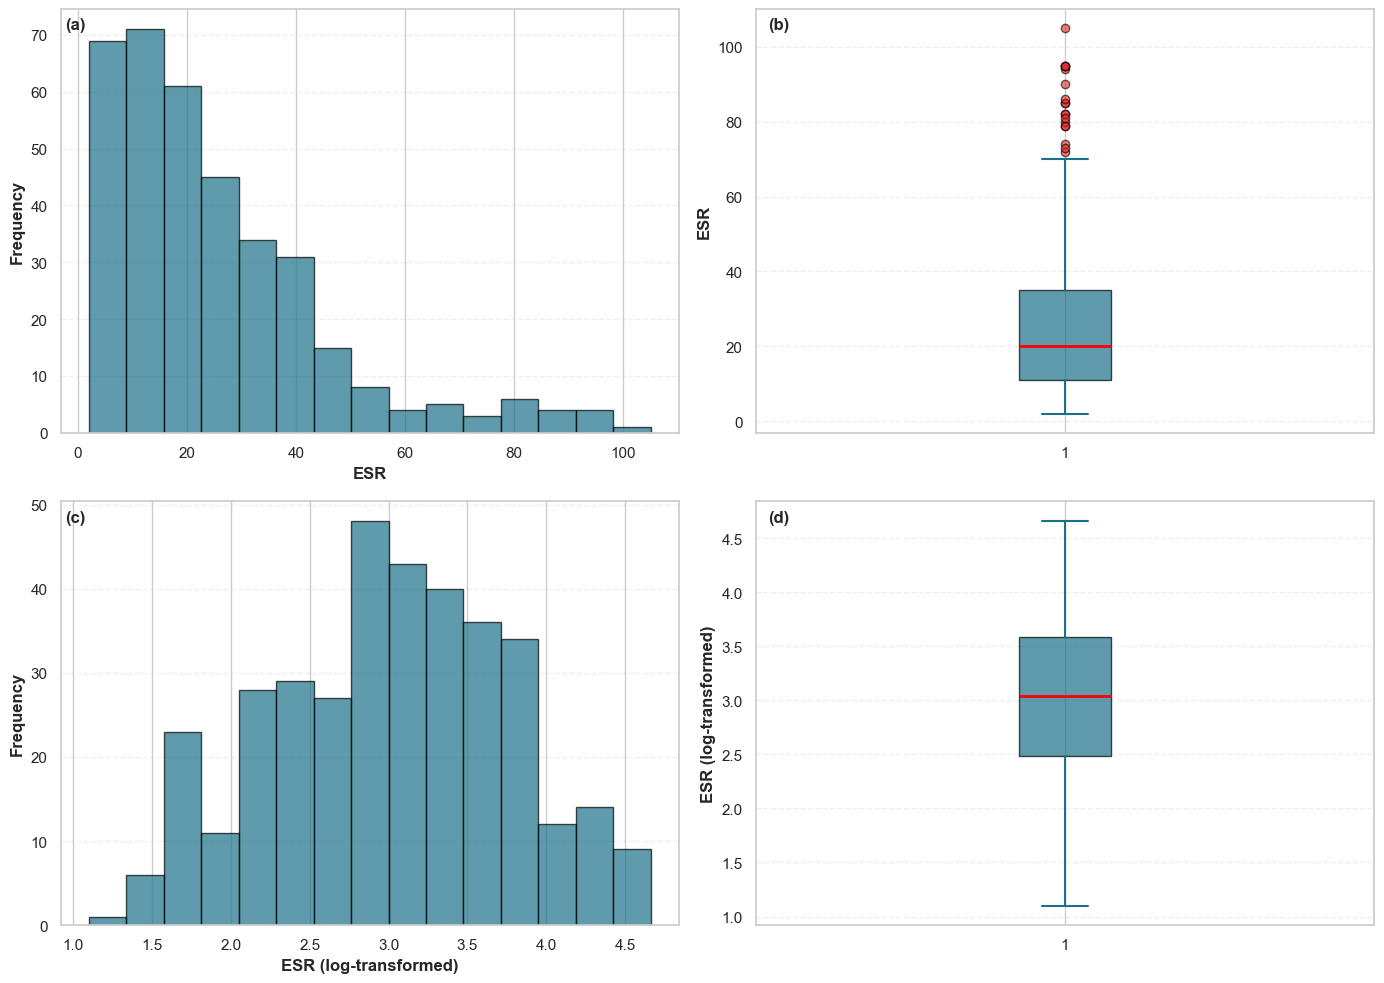

In [65]:
# CRP and ESR Comparison (Original vs Log-Transformed)
df_cleaned['log_crp_normalized'] = np.log1p(df_cleaned['crp_normalized'])

df_cleaned['log_esr'] = np.log1p(df_cleaned['esr'])
#previous esr value (lagged by one visit) for each patient
df_cleaned['log_esr_lag1'] = df_cleaned.groupby('patient_id')['log_esr'].shift(1)
df_cleaned['esr_lag1'] = df_cleaned.groupby('patient_id')['esr'].shift(1)

df_cleaned['log_disease_duration'] = np.log1p(df_cleaned['disease_duration'])


variables = [
    ('CRP', 'crp_normalized', 'log_crp_normalized'),
    ('ESR', 'esr', 'log_esr'),
]

for var_name, col_orig, col_log in variables:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    #Original variables
    
    #Histogram
    axes[0, 0].hist(
        df_cleaned[col_orig].dropna(),
        bins=15,
        color="#1B7189",
        edgecolor='black',
        alpha=0.7
    )
    axes[0, 0].set_xlabel(var_name, fontweight='bold')
    axes[0, 0].set_ylabel('Frequency', fontweight='bold')
    axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')
    axes[0, 0].text(0.0075, 0.98, '(a)', transform=axes[0, 0].transAxes, fontsize=12, fontweight='bold', 
                    verticalalignment='top')
    
    #Boxplot
    bp1 = axes[0, 1].boxplot(df_cleaned[col_orig].dropna(), vert=True, patch_artist=True)
    bp1['boxes'][0].set_facecolor('#1B7189')
    bp1['boxes'][0].set_alpha(0.7)
    for whisker in bp1['whiskers']:
        whisker.set(linewidth=1.5, color='#1B7189')
    for cap in bp1['caps']:
        cap.set(linewidth=1.5, color='#1B7189')
    for median in bp1['medians']:
        median.set(linewidth=2, color='red')
    for flier in bp1['fliers']:
        flier.set(marker='o', markerfacecolor='#e72828', markersize=6, alpha=0.6)
    axes[0, 1].set_ylabel(var_name, fontweight='bold')
    axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')
    axes[0, 1].text(0.02, 0.98, '(b)', transform=axes[0, 1].transAxes, fontsize=12, fontweight='bold', 
                    verticalalignment='top')
    
    #Log transformed variables
    #Histogram
    axes[1, 0].hist(
        df_cleaned[col_log].dropna(),
        bins=15,
        color="#1B7189",
        edgecolor='black',
        alpha=0.7
    )
    axes[1, 0].set_xlabel(f'{var_name} (log-transformed)', fontweight='bold')
    axes[1, 0].set_ylabel('Frequency', fontweight='bold')
    axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')
    axes[1, 0].text(0.0075, 0.98, '(c)', transform=axes[1, 0].transAxes, fontsize=12, fontweight='bold', 
                    verticalalignment='top')
    
    #Boxplot
    bp2 = axes[1, 1].boxplot(df_cleaned[col_log].dropna(), vert=True, patch_artist=True)
    bp2['boxes'][0].set_facecolor('#1B7189')
    bp2['boxes'][0].set_alpha(0.7)
    for whisker in bp2['whiskers']:
        whisker.set(linewidth=1.5, color='#1B7189')
    for cap in bp2['caps']:
        cap.set(linewidth=1.5, color='#1B7189')
    for median in bp2['medians']:
        median.set(linewidth=2, color='red')
    for flier in bp2['fliers']:
        flier.set(marker='o', markerfacecolor='#e72828', markersize=6, alpha=0.6)
    axes[1, 1].set_ylabel(f'{var_name} (log-transformed)', fontweight='bold')
    axes[1, 1].grid(axis='y', alpha=0.3, linestyle='--')
    axes[1, 1].text(0.02, 0.98, '(d)', transform=axes[1, 1].transAxes, fontsize=12, fontweight='bold', 
                    verticalalignment='top')
    
    plt.tight_layout()
    plt.show()

In [46]:
df_cleaned['disease_duration_squared']= df_cleaned['disease_duration'] ** 2

#### Categorical variables

In [47]:
df_cleaned['mtx_dose_category'].value_counts(dropna=False)

mtx_dose_category
0 mg        175
11-20 mg    150
1-10 mg      42
21-25 mg     26
Name: count, dtype: int64

In [48]:
df_cleaned['steroid_dose_category'].value_counts(sort=False)

steroid_dose_category
0 mg       245
1-10 mg    139
>10mg        9
Name: count, dtype: int64

In [53]:
df_cleaned['csdmard_name'].value_counts(dropna=False)

csdmard_name
Hydroxychloroquine                   211
none                                 170
Leflunomide                            5
Mycophenolate, Hydroxychloroquine      2
Azathioprine                           1
Sulfasalazine, Leflunomide             1
Hydroxychloroquine, Sulfasalazine      1
Colchicine                             1
Colchicine, Hydroxychloroquine         1
Name: count, dtype: int64

In [55]:
df_cleaned['mtx_use'].value_counts(dropna=False)

mtx_use
1    219
0    174
Name: count, dtype: Int64

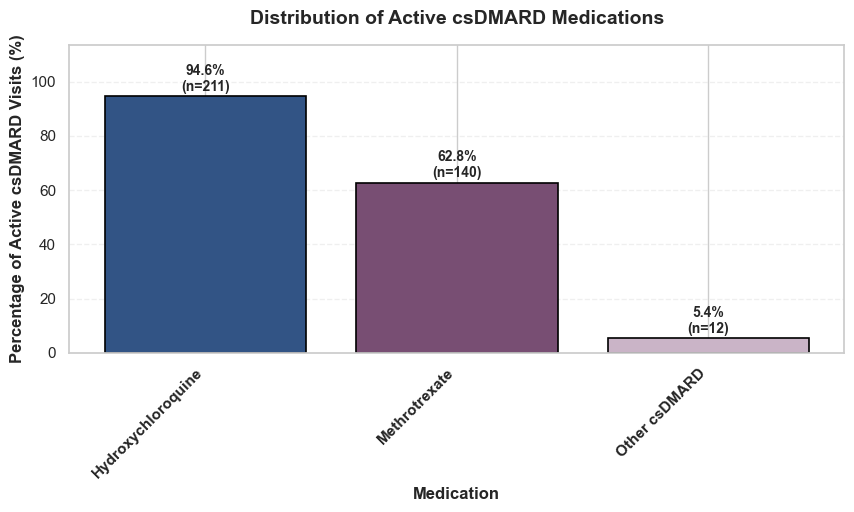

In [61]:
#Filter active csDMARD users and build medication list
main_drugs = ['Hydroxychloroquine', 'MTX']
df_active_csdmard = df_cleaned[df_cleaned['csdmard_use'] == 1].copy()

medications = []
for _, row in df_active_csdmard.iterrows():
    if row['mtx_use'] == 1:
        medications.append('Methrotrexate')
    drug = row['csdmard_name']
    if pd.notna(drug) and drug != 'none':
        medications.append(drug if drug in main_drugs else 'Other csDMARD')

#Calculate percentages
med_counts = pd.Series(medications).value_counts()
med_percentages = (med_counts / len(df_active_csdmard) * 100).sort_values(ascending=False)

plt.figure(figsize=(10, 4))
bars = plt.bar(range(len(med_percentages)), med_percentages.values,
               color=["#325485", "#784E73", "#CAB4C7"], edgecolor='black', linewidth=1.2)
plt.title('Distribution of Active csDMARD Medications', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Medication', fontsize=12, fontweight='bold')
plt.ylabel('Percentage of Active csDMARD Visits (%)', fontsize=12, fontweight='bold')
plt.ylim(0, med_percentages.max() * 1.2)
plt.xticks(range(len(med_percentages)), med_percentages.index, rotation=45, ha='right', fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')

for bar, pct, count in zip(bars, med_percentages.values, med_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f"{pct:.1f}%\n(n={count})", ha='center', fontweight='bold', fontsize=10)

plt.show()

- Dominant Regimens: Hydroxychloroquine was utilized in 94.6% ($n = 211$) and Methotrexate (MTX) in 62.7% ($n = 140$) of active visits. Low-frequency agents (Leflunomide, Azathioprine) were consolidated into an other_csDMARD category (5.4%, $n = 12$).  
- Clinical Context: The cumulative frequency exceeding 100% reflects standard combination therapy to suppress joint inflammation rather than mutually exclusive treatment lines.

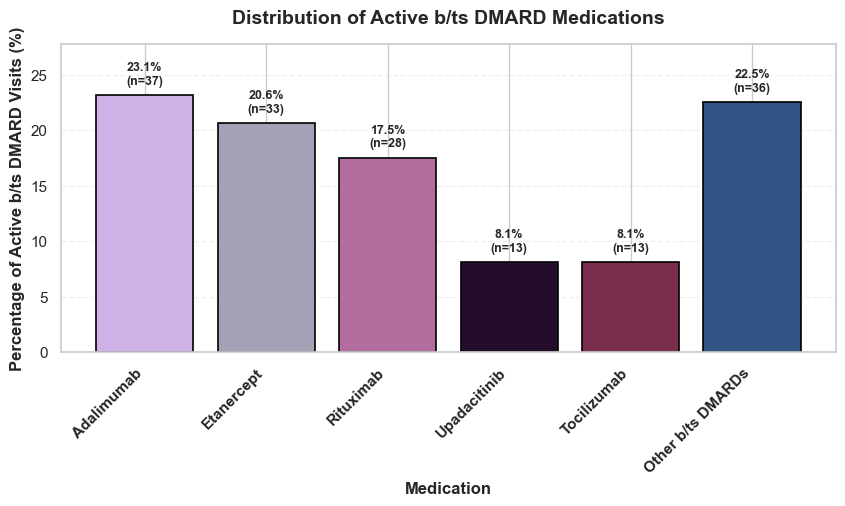

In [63]:
#Filter active b/tsDMARD users
df_active_b_ts = df_cleaned[df_cleaned['b_ts_dmard_use'] == 1].copy()

medications_b_ts = []
for _, row in df_active_b_ts.iterrows():
    drug = row['b_ts_dmard_name']
    if pd.notna(drug) and drug != 'none':
        medications_b_ts.append(drug)

#Calculate counts and percentages
med_counts_b_ts = pd.Series(medications_b_ts).value_counts()
med_percentages_b_ts = (med_counts_b_ts / len(df_active_b_ts) * 100).sort_values(ascending=False)

#Keep top 5 medications, group the rest as "Other b/ts DMARDs"
top_n = 5
if len(med_percentages_b_ts) > top_n:
    top_meds = med_percentages_b_ts.head(top_n)
    other_count = med_counts_b_ts[top_n:].sum()
    other_pct = (other_count / len(df_active_b_ts) * 100)
    
    med_counts_b_ts = pd.concat([med_counts_b_ts.head(top_n), pd.Series({'Other b/ts DMARDs': other_count})])
    med_percentages_b_ts = pd.concat([top_meds, pd.Series({'Other b/ts DMARDs': other_pct})])

plt.figure(figsize=(10, 4))
palette_b_ts = ["#CEB1E7", "#A5A0B6", "#B26C9E", "#240D2B", "#7B2D4D", "#325485"]
bars = plt.bar(range(len(med_percentages_b_ts)), med_percentages_b_ts.values,
               color=palette_b_ts[:len(med_percentages_b_ts)], edgecolor='black', linewidth=1.2)
plt.title('Distribution of Active b/ts DMARD Medications', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Medication', fontsize=12, fontweight='bold')
plt.ylabel('Percentage of Active b/ts DMARD Visits (%)', fontsize=12, fontweight='bold')
plt.ylim(0, med_percentages_b_ts.max() * 1.2)
plt.xticks(range(len(med_percentages_b_ts)), med_percentages_b_ts.index, rotation=45, ha='right', fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')

for bar, pct, count in zip(bars, med_percentages_b_ts.values, med_counts_b_ts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{pct:.1f}%\n(n={count})", ha='center', fontweight='bold', fontsize=9)

plt.show()

- Prescription Patterns: Anti-TNF agents predominated, led by Adalimumab (23.1%, $n = 37$) and Etanercept (20.6%, $n = 33$), followed by Rituximab (17.5%, $n = 28$), with Upadacitinib and Tocilizumab at 8.1% ($n = 13$) each. Low-frequency agents (e.g., Abatacept, Infliximab) were aggregated into other_b/tsDMARD (22.5%, $n = 36$).  
- Clinical Context: Total utilization sums to exactly 100%, aligning with clinical guidelines that strictly contraindicate concurrent b/tsDMARD use due to elevated risk of severe immunosuppression.

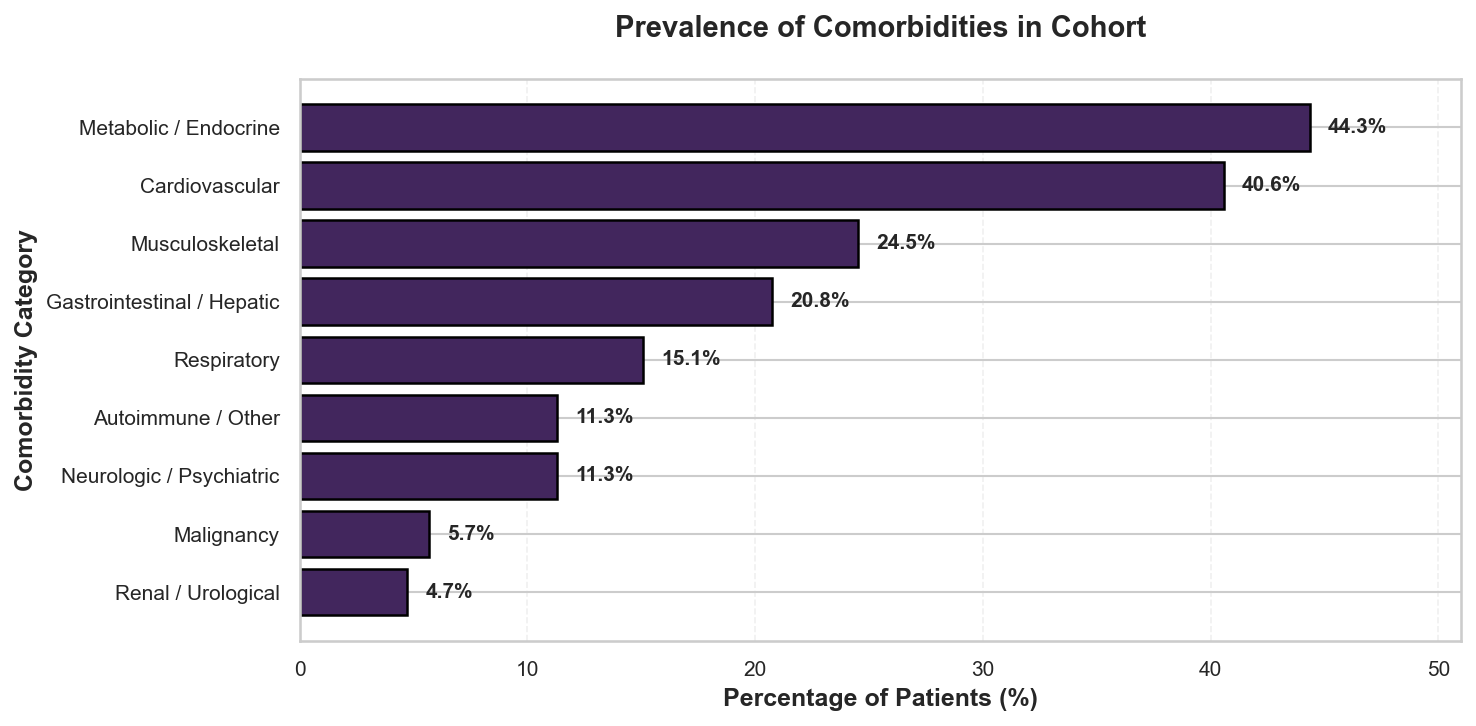

count    393.000000
mean       2.267176
std        1.864646
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        7.000000
Name: comorbidity_count, dtype: float64


In [70]:
#Define comorbidity column names
comorb_cols = [
    'comorb_cardiovascular', 
    'comorb_metabolic_endocrine', 
    'comorb_respiratory', 
    'comorb_renal_urological',
    'comorb_gastrointestinal_hepatic',
    'comorb_malignancy',
    'comorb_musculoskeletal',
    'comorb_neurologic_psychiatric',
    'comorb_autoimmune_other'
]

#Create mapping from column names to readable labels for visualization
comorb_label_map = {
    "comorb_cardiovascular": "Cardiovascular",
    "comorb_metabolic_endocrine": "Metabolic / Endocrine",
    "comorb_respiratory": "Respiratory",
    "comorb_renal_urological": "Renal / Urological",
    "comorb_gastrointestinal_hepatic": "Gastrointestinal / Hepatic",
    "comorb_malignancy": "Malignancy",
    "comorb_musculoskeletal": "Musculoskeletal",
    "comorb_neurologic_psychiatric": "Neurologic / Psychiatric",
    "comorb_autoimmune_other": "Autoimmune / Other"
}

#Calculate comorbidity prevalence at patient level. Group by patient and take max (since each patient can have multiple visits)
patient_comorb = df_cleaned.groupby('patient_id')[comorb_cols].max()
#Count total number of patients with each comorbidity, sorted in descending order
comorb_counts = patient_comorb.sum().sort_values(ascending=False)
#Calculate total number of unique patients
n_patients = patient_comorb.shape[0]
#Calculate percentage prevalence for each comorbidity
comorb_percent = (comorb_counts / n_patients * 100)
#Apply readable labels to the percentage and count data
comorb_percent_named = comorb_percent.rename(index=comorb_label_map)
comorb_counts_named = comorb_counts.rename(index=comorb_label_map)
y_labels = comorb_percent_named.index.astype(str).to_list()
x_percent = comorb_percent_named.to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
graph = ax.barh( y_labels, x_percent, color='#42265D', edgecolor='black', linewidth=1.2)

ax.set_title('Prevalence of Comorbidities in Cohort', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Percentage of Patients (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Comorbidity Category', fontsize=12, fontweight='bold')
ax.tick_params(axis='both', labelsize=10)
ax.set_xlim(0, max(x_percent) * 1.15)
ax.invert_yaxis()

# Add percentage labels on bars
for i, (p, pct) in enumerate(zip(graph, x_percent)):
    width = p.get_width()
    ax.text(width + 0.8, p.get_y() + p.get_height() / 2, f'{pct:.1f}%', ha='left', va='center', fontweight='bold', fontsize=10)

ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()
print(df_cleaned['comorbidity_count'].describe())

- Prevalence Profile: Metabolic/Endocrine disorders (44.3%) and Cardiovascular conditions (40.6%) were the predominant systemic comorbidities, consistent with known chronic inflammatory complications in RA (e.g., hypertension, dyslipidemia). Musculoskeletal (24.5%) and Gastrointestinal/Hepatic (20.8%) disorders followed.

- Multimorbidity Dynamics: Cumulative frequencies exceed 100%, indicating widespread multi-system involvement. Patients present with an average of ~2.3 concurrent conditions.

In [71]:
df_cleaned['treatment_decision_grouped'].value_counts(normalize=True, dropna=False) * 100

treatment_decision_grouped
escalation_or_switch    31.552163
baseline_no_decision    26.972010
stable_no_change        26.717557
tapering_or_stop        14.758270
Name: proportion, dtype: float64

### Bivariate Analysis
#### Continuous variables

Mann-Whitney U-test

In [73]:
#Statistical comparison of continuous variables between flare groups
features_to_compare = {
    'das28_score': 'DAS28 Score',
    'das28_change': 'DAS28 Change',
    'log_esr': 'Log ESR',
    'log_esr_lag1': 'Log ESR (Lagged 1 Visit)',
    'log_crp_normalized': 'Log CRP',
    'age_at_visit': 'Age at Visit',
    'disease_duration': 'Disease Duration',
    'disease_duration_squared': 'Disease Duration Squared',
    'days_since_last_visit': 'Days Since Last Visit',
    'treatment_count': 'Treatment Count',
    'comorbidity_count': 'Comorbidity Count',
    'mtx_dose': 'MTX dose',
    'steroid_dose': 'Steroid dose'
}

comparison_results = []

for col, label in features_to_compare.items():
    #Split by flare status
    no_flare = df_cleaned[df_cleaned['flare_next_visit'] == 0][col].dropna()
    flare = df_cleaned[df_cleaned['flare_next_visit'] == 1][col].dropna()
    
    #Descriptive statistics
    no_flare_mean = no_flare.mean()
    no_flare_sd = no_flare.std()
    no_flare_median = no_flare.median()
    no_flare_q1 = no_flare.quantile(0.25)
    no_flare_q3 = no_flare.quantile(0.75)
    
    flare_mean = flare.mean()
    flare_sd = flare.std()
    flare_median = flare.median()
    flare_q1 = flare.quantile(0.25)
    flare_q3 = flare.quantile(0.75)
    
    #Mann-Whitney U test
    statistic, p_value = mannwhitneyu(no_flare, flare, alternative='two-sided')
    
    #Effect size (rank-biserial correlation)
    n1, n2 = len(no_flare), len(flare)
    r = 1 - (2*statistic) / (n1 * n2)
    
    comparison_results.append({
        'Variable': label,
        'No Flare (Mean±SD)': f'{no_flare_mean:.2f}±{no_flare_sd:.2f}',
        'No Flare (Median[IQR])': f'{no_flare_median:.2f}[{no_flare_q1:.2f}-{no_flare_q3:.2f}]',
        'Flare (Mean±SD)': f'{flare_mean:.2f}±{flare_sd:.2f}',
        'Flare (Median[IQR])': f'{flare_median:.2f}[{flare_q1:.2f}-{flare_q3:.2f}]',
        'p-value': f'{p_value:.4f}',
        'Significant': 'Yes' if p_value < 0.05 else 'No',
        'Effect Size (r)': f'{abs(r):.3f}'
    })

comparison_df = pd.DataFrame(comparison_results)
print("Mann-Whitney U Test Results: No Flare vs Flare at Next Visit")
print("="*140)
print(comparison_df.to_string(index=False))
print("\nNote: p-value < 0.05 indicates statistically significant difference")
print("Effect size r: |r| < 0.1 (negligible), 0.1-0.3 (small), 0.3-0.5 (medium), > 0.5 (large)")

Mann-Whitney U Test Results: No Flare vs Flare at Next Visit
                Variable No Flare (Mean±SD) No Flare (Median[IQR]) Flare (Mean±SD) Flare (Median[IQR]) p-value Significant Effect Size (r)
             DAS28 Score          3.09±1.12        3.04[2.20-3.73]       4.09±1.20     4.09[3.30-4.90]  0.0000         Yes           0.475
            DAS28 Change         -0.21±0.82       0.00[-0.35-0.00]      -0.00±0.92    0.00[-0.11-0.10]  0.0185         Yes           0.173
                 Log ESR          2.87±0.78        2.89[2.20-3.44]       3.26±0.64     3.22[2.77-3.69]  0.0000         Yes           0.281
Log ESR (Lagged 1 Visit)          2.94±0.78        2.94[2.40-3.56]       3.20±0.65     3.26[2.77-3.64]  0.0124         Yes           0.190
                 Log CRP          0.60±0.53        0.47[0.18-0.83]       0.90±0.76     0.69[0.34-1.14]  0.0003         Yes           0.249
            Age at Visit        60.18±12.16     61.00[52.50-70.00]     58.85±12.44  57.00[50.00-68.75]  0

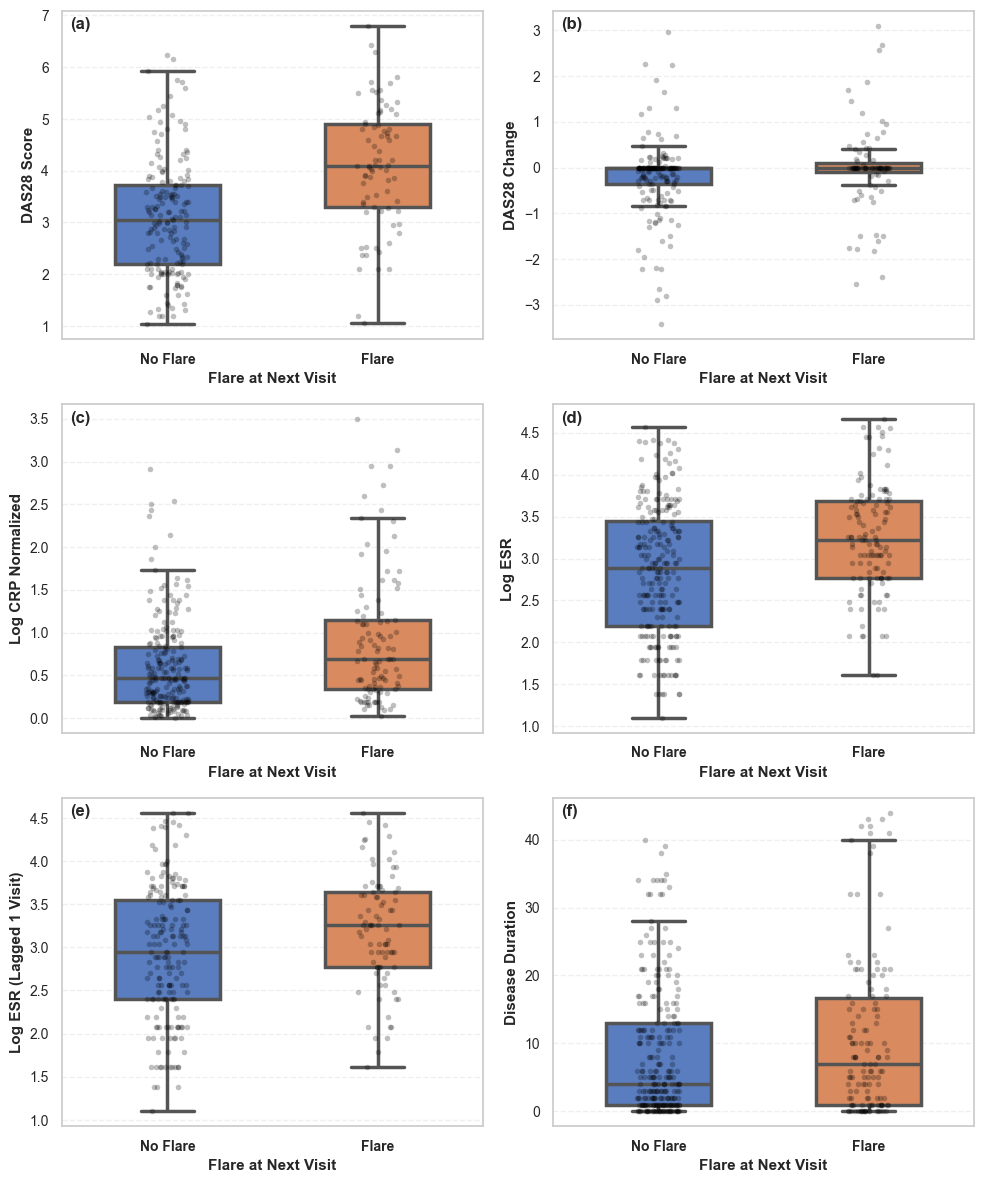

In [78]:
continuous_cols_stats = {
    'das28_score': 'DAS28 Score',
    'das28_change': 'DAS28 Change',
    'log_crp_normalized': 'Log CRP Normalized',
    'log_esr': 'Log ESR',   
    'log_esr_lag1': 'Log ESR (Lagged 1 Visit)',
    'disease_duration': 'Disease Duration',
    
}

sns.set_style("whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(10, 12), dpi=100)
axes = axes.flatten()

for idx, (col_name, col_label) in enumerate(continuous_cols_stats.items()):
    ax = axes[idx]
    
    #Boxplot
    sns.boxplot(
        data=df_cleaned, x='flare_next_visit', y=col_name,
        palette='muted', hue='flare_next_visit', width=0.5,
        linewidth=2.5, fliersize=0, ax=ax, legend=False)
    
    #Strip plot
    sns.stripplot(
        data=df_cleaned, x='flare_next_visit', y=col_name,
        color='black', alpha=0.25, size=4, jitter=True, ax=ax)
    
    #Calculate Mann-Whitney U test
    no_flare = df_cleaned[df_cleaned['flare_next_visit'] == 0][col_name].dropna()
    flare = df_cleaned[df_cleaned['flare_next_visit'] == 1][col_name].dropna()
    statistic, p_value = mannwhitneyu(no_flare, flare, alternative='two-sided')
    
    # Annotation
    ax.set_xlabel('Flare at Next Visit', fontsize=11, fontweight='bold')
    ax.set_ylabel(col_label, fontsize=11, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No Flare', 'Flare'], fontsize=10, fontweight='bold')
    ax.tick_params(axis='y', labelsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
   
    ax.text(0.02, 0.98, f'({chr(97 + idx)})', transform=ax.transAxes, 
            fontsize=12, fontweight='bold', verticalalignment='top')
plt.tight_layout()
plt.show()

Distributional shifts between non-flare ($0$) and flare ($1$) visits reveal distinct clinical signals across disease activity scores, acute inflammation, and patient history:  
- Disease Activity (das28_score & das28_change): Patients who flare exhibit higher baseline DAS28 scores with broader variability, alongside a positive trajectory  
- ($\Delta \text{DAS28}$) indicating symptom worsening rather than stability.  
- Inflammatory Biomarkers (ESR, CRP, esr_lag1): Both acute-phase reactants show elevated medians prior to a flare. ESR displays tighter clustering around elevated values, while CRP exhibits greater variance with extreme spikes. The lagged marker (esr_lag1) tracks current ESR, confirming persistent inflammation.  
- Disease Chronicity (disease_duration): While both groups contain newly diagnosed patients, the flare cohort has an older median duration (~7.0 vs. ~4.0 years) and a prominent long-tail ($\le 40$ years), identifying established, chronic RA as a higher-risk subgroup.

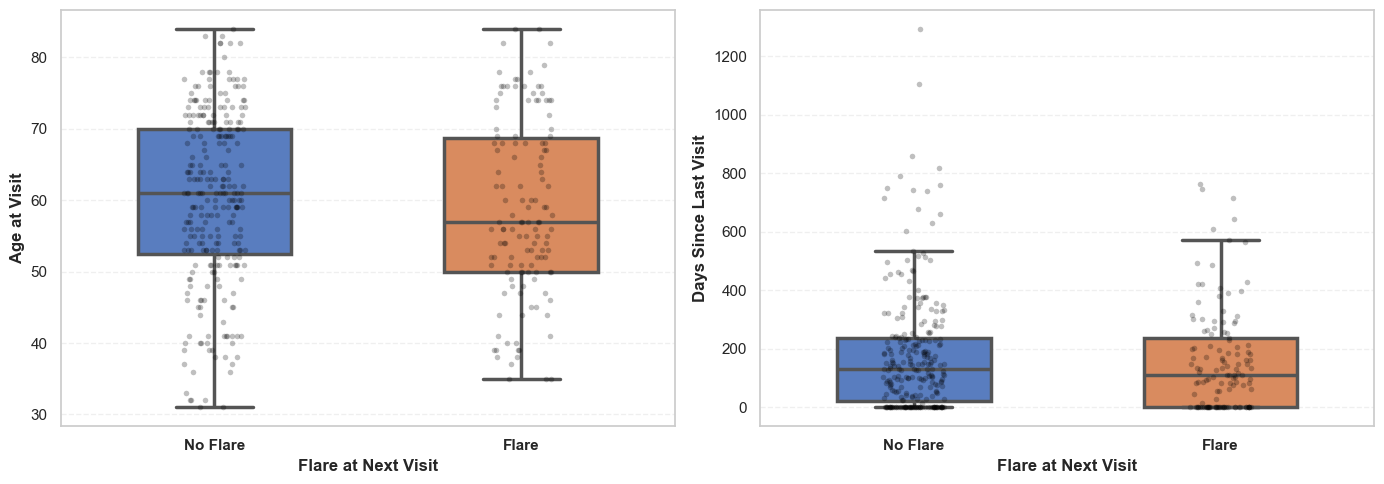

In [80]:
columns = {
'Age at Visit': df_cleaned['age_at_visit'],
'Days Since Last Visit': df_cleaned['days_since_last_visit']
}

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (col_name, col_data) in enumerate(columns.items()):
    ax = axes[idx]

    sns.boxplot(data=df_cleaned, x='flare_next_visit', y=col_data, palette='muted', hue='flare_next_visit', width=0.5, linewidth=2.5, fliersize=0, legend=False, ax=ax)
    sns.stripplot(data=df_cleaned, x='flare_next_visit', y=col_data, color='black', alpha=0.25, size=4, jitter=True, ax=ax)
    
    ax.set_xlabel('Flare at Next Visit', fontsize=12, fontweight='bold')
    ax.set_ylabel(col_name, fontsize=12, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No Flare', 'Flare'], fontsize=11, fontweight='bold')
    ax.tick_params(axis='y', labelsize=11)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Features such as age_at_visit and days_since_last_visit exhibit near-identical medians and overlapping interquartile ranges across both cohorts, indicating limited visual separation between flare and non-flare encounters.

### Binary/Categorical Variables

In [85]:
df_cleaned['age_bins'] = pd.cut(df_cleaned['age_at_visit'], bins=[0, 40, 50, 60, 70, 110], right=True, labels=['under_40', '40-49', '50-59', '60-69', '70_plus'], ordered=True)
df_cleaned['das28_bins'] = pd.cut(df_cleaned['das28_score'], bins=[0, 3.2, 5.1, 10], right=True, labels=['Remission/Low', 'Moderate', 'High'], ordered=True)

In [87]:
# Define feature groups
feature_groups = {
    'Demographics': ['gender', 'age_bins'],
    'Clinical & Disease Status': [
        'rf_status',
        'anti_ccp_status',
        'previous_flare',
        'das28_bins',
        'inflammation_flag',
        'visit_type',
    ],
    'Treatment': ['mtx_use', 'mtx_dose_category', 'steroid_use', 'steroid_dose_category', 'csdmard_use', 'b_ts_dmard_use', 'treatment_decision_grouped'],
    'Comorbidities': comorb_cols,
}

records = []

for group_name, cols in feature_groups.items():
  for col in cols:
    if col not in df_cleaned.columns:
      continue

    #Cross-tabulation & Chi-Square test
    ct = pd.crosstab(df_cleaned[col], df_cleaned['flare_next_visit'])
    chi2, p_val, _, _ = chi2_contingency(ct)

    #Effect size: Cramer's V
    n = ct.sum().sum()
    min_dim = min(ct.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0.0

    records.append({
        'Feature Group': group_name,
        'Feature': col,
        'Chi2': round(chi2, 2),
        'p-value': f'< 0.001' if p_val < 0.001 else f'{p_val:.4f}',
        "Cramer's V": round(cramers_v, 3),
        'Significant (α=0.05)': 'Yes' if p_val < 0.05 else 'No',
    })

#Create a DataFrame from the records and sort by Feature Group and Cramer's V
cat_summary_df = pd.DataFrame(records).sort_values(
    by=['Feature Group', "Cramer's V"], ascending=[True, False]
)

cat_summary_df.reset_index(drop=True, inplace=True)
cat_summary_df

,Feature Group,Feature,Chi2,p-value,Cramer's V,Significant (α=0.05)
0,Clinical & Disease Status,das28_bins,32.49,< 0.001,0.362,Yes
1,Clinical & Disease Status,inflammation_flag,10.91,< 0.001,0.171,Yes
2,Clinical & Disease Status,previous_flare,5.61,0.0178,0.120,Yes
3,Clinical & Disease Status,visit_type,1.72,0.1891,0.066,No
4,Clinical & Disease Status,anti_ccp_status,0.77,0.3796,0.044,No
5,Clinical & Disease Status,rf_status,0.12,0.7273,0.018,No
6,Comorbidities,comorb_musculoskeletal,3.09,0.0788,0.089,No
7,Comorbidities,comorb_malignancy,2.37,0.1238,0.078,No
8,Comorbidities,comorb_metabolic_endocrine,2.23,0.1356,0.075,No
9,Comorbidities,comorb_cardiovascular,2.12,0.1451,0.073,No


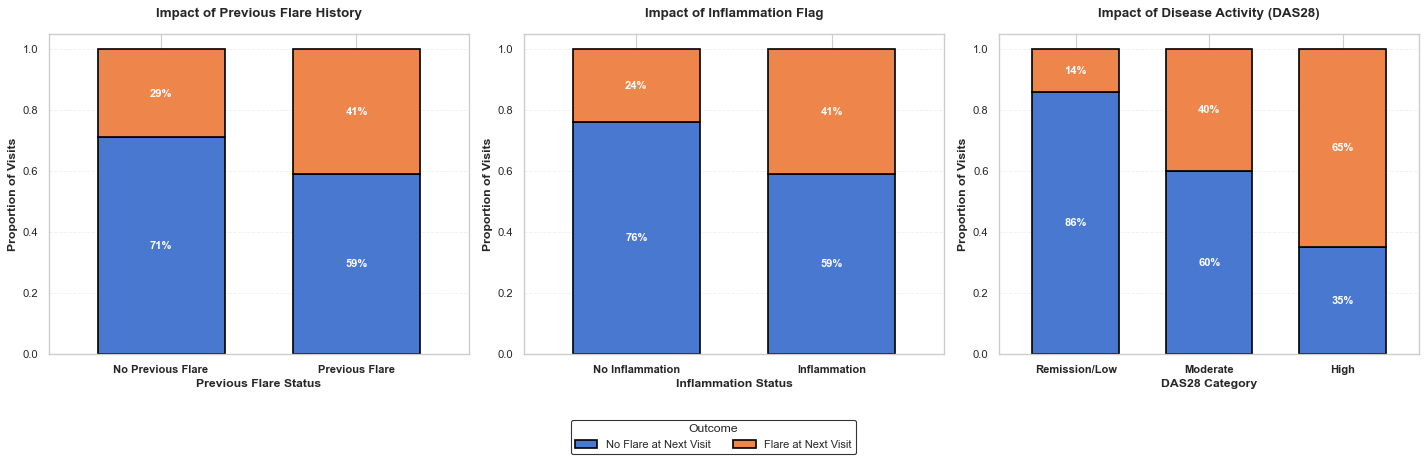

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), dpi=80)
colors = sns.color_palette('muted', 2)

plot_configs = [
    {
        'col': 'previous_flare',
        'ax': axes[0],
        'title': 'Impact of Previous Flare History',
        'xlabel': 'Previous Flare Status',
        'xticklabels': ['No Previous Flare', 'Previous Flare'],
    },
    {
        'col': 'inflammation_flag',
        'ax': axes[1],
        'title': 'Impact of Inflammation Flag',
        'xlabel': 'Inflammation Status',
        'xticklabels': ['No Inflammation', 'Inflammation'],
    },
    {
        'col': 'das28_bins',
        'ax': axes[2],
        'title': 'Impact of Disease Activity (DAS28)',
        'xlabel': 'DAS28 Category',
        'xticklabels': ['Remission/Low', 'Moderate', 'High'],
    },
]

for cfg in plot_configs:
  ax = cfg['ax']
  ct = pd.crosstab(df_cleaned[cfg['col']], df_cleaned['flare_next_visit'], normalize='index',).round(2)

  ct.plot(
      kind='bar',
      stacked=True,
      ax=ax,
      color=colors,
      edgecolor='black',
      linewidth=1.5,
      width=0.65,
      legend=False,
  )

  for c in ax.containers:
    ax.bar_label(
        c,
        labels=[f'{v.get_height()*100:.0f}%' for v in c],
        label_type='center',
        color='white',
        fontweight='bold',
        fontsize=10,
    )

  ax.set_title(cfg['title'], fontsize=12, fontweight='bold', pad=15)
  ax.set_xlabel(cfg['xlabel'], fontsize=11, fontweight='bold')
  ax.set_ylabel('Proportion of Visits', fontsize=11, fontweight='bold')
  ax.set_xticklabels(cfg['xticklabels'], rotation=0, fontsize=10, fontweight='bold')
  ax.tick_params(axis='y', labelsize=10)
  ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
  ax.set_axisbelow(True)
  ax.set_ylim(0, 1.05)

#Shared legend at the bottom
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles=axes[0].containers,
    labels=['No Flare at Next Visit', 'Flare at Next Visit'],
    title='Outcome',
    title_fontsize=11,
    fontsize=10,
    frameon=True,
    edgecolor='black',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.06),
    ncol=2,
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.show()

- Prior Flare History (previous_flare): Patients with a documented history of flares show a marked upward shift in subsequent flare probability, confirming an autoregressive disease pattern where past instability elevates recurrence risk.
- Composite Inflammation (inflammation_flag): The engineered flag capturing joint elevations in acute-phase reactants (CRP or ESR) demonstrates clear discriminative separation, identifying an active inflammatory state as a strong baseline predictor for near-term flare occurrence.
- DAS28 Bins: Displays a clear, stepwise risk escalation. Baseline disease activity advances from Remission/Low to Moderate and High, subsequent flare rates increase progressively.

### Correlation Matrix

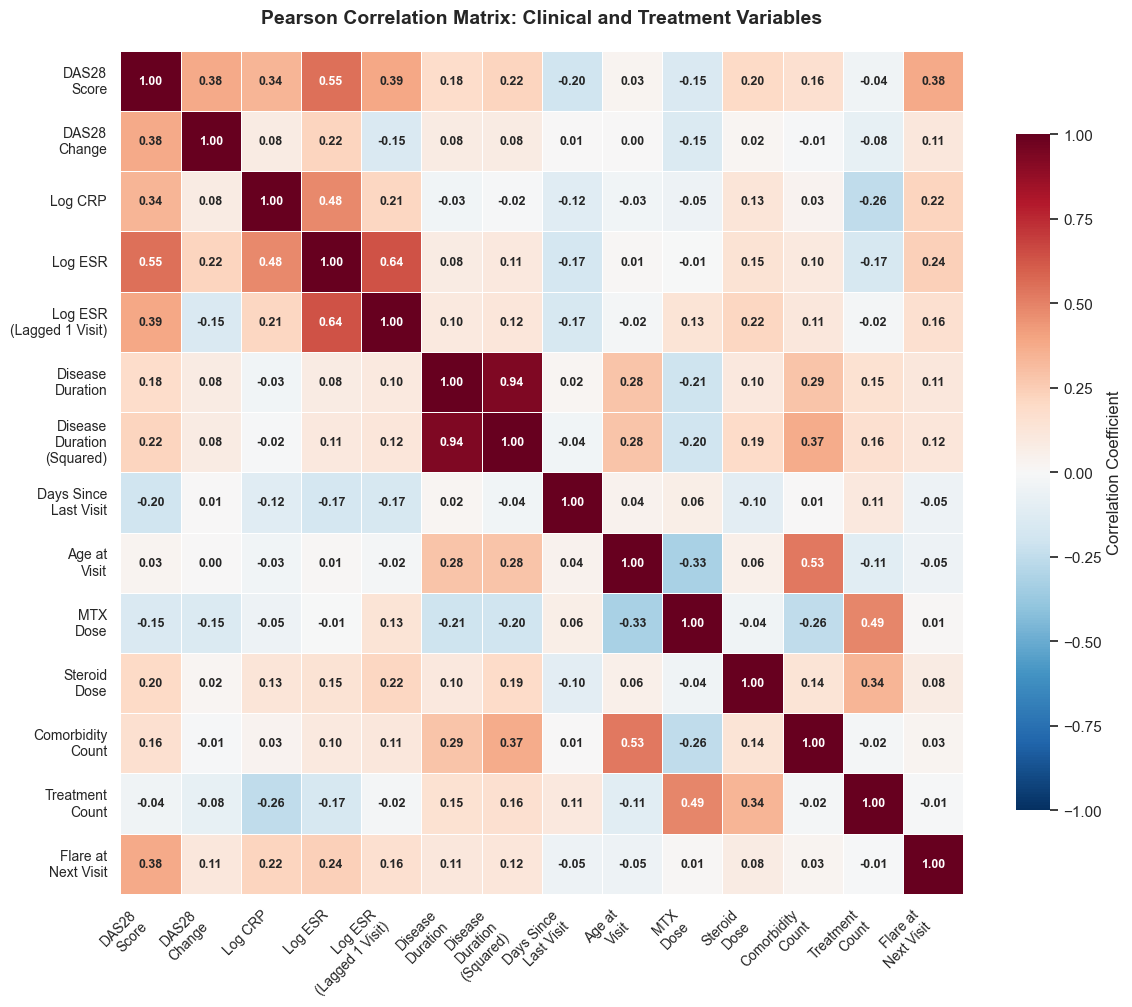

In [98]:
correlation_columns = [
    'das28_score', 'das28_change', 'log_crp_normalized', 'log_esr', 'log_esr_lag1',
    'disease_duration', 'disease_duration_squared', 'days_since_last_visit', 'age_at_visit', 'mtx_dose', 'steroid_dose', 
    'comorbidity_count', 'treatment_count', 'flare_next_visit'
]

col_labels = [
    'DAS28\nScore',
    'DAS28\nChange',
    'Log CRP',
    'Log ESR',
    'Log ESR\n(Lagged 1 Visit)',
    'Disease\nDuration',
    'Disease\nDuration\n(Squared)',
    'Days Since\nLast Visit',
    'Age at\nVisit',
    'MTX\nDose',
    'Steroid\nDose',
    'Comorbidity\nCount',
    'Treatment\nCount',
    'Flare at\nNext Visit'
]

corr_matrix = df_cleaned[correlation_columns].corr()

fig, ax = plt.subplots(figsize=(12, 10), dpi=100)
sns.heatmap(
    corr_matrix,
    vmin=-1, vmax=1, center=0,
    cmap='RdBu_r',
    annot=True, 
    fmt='.2f',
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient', 'shrink': 0.8},
    xticklabels=col_labels,
    yticklabels=col_labels,
    ax=ax,
    annot_kws={'size': 9, 'fontweight': 'bold'}
)

ax.set_title('Pearson Correlation Matrix: Clinical and Treatment Variables', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

### Cramer's V Matrix

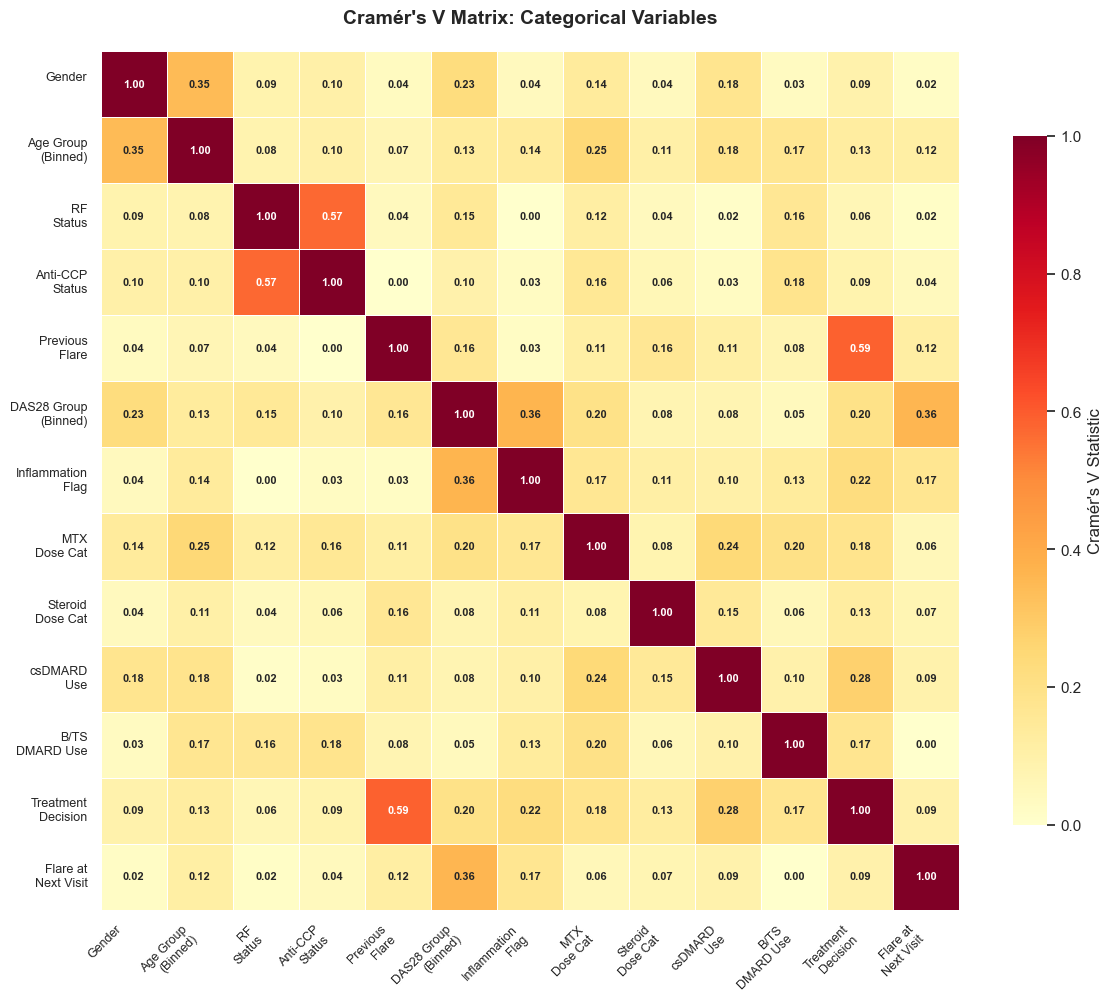

In [103]:
def cramers_v(x, y):
    """
    Calculate Cramér's V statistic for categorical-categorical association.
    V ranges from 0 to 1, with 0 indicating no association and 1 indicating perfect association.
    """
    #Create contingency table
    confusion_matrix = pd.crosstab(x, y)
    
    #Calculate chi-squared statistic
    chi2 = chi2_contingency(confusion_matrix)[0]
    
    #Get dimensions
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    
    #Avoid division by zero
    if min_dim == 0:
        return 0
    
    #Calculate Cramér's V
    v = np.sqrt(chi2 / (n * min_dim))
    
    return v

categorical_columns = [
    'gender',  
    'age_bins',                
    'rf_status',                 
    'anti_ccp_status',  
    'previous_flare',
    'das28_bins',    
    'inflammation_flag',  
    'mtx_dose_category',
    'steroid_dose_category',
    'csdmard_use',            
    'b_ts_dmard_use',                       
    'treatment_decision_grouped',          
    'flare_next_visit'          
]

cat_labels = [
    'Gender\n',
    'Age Group\n(Binned)',
    'RF\nStatus',
    'Anti-CCP\nStatus',
    'Previous\nFlare',
    'DAS28 Group\n(Binned)',
    'Inflammation\nFlag',
    'MTX\nDose Cat',
    'Steroid\nDose Cat',
    'csDMARD\nUse',
    'B/TS\nDMARD Use',
    'Treatment\nDecision',
    'Flare at\nNext Visit'
]

#Calculate Cramér's V matrix
n_cat_vars = len(categorical_columns)
cramers_matrix = np.zeros((n_cat_vars, n_cat_vars))

for i, col1 in enumerate(categorical_columns):
    for j, col2 in enumerate(categorical_columns):
        if i == j:
            cramers_matrix[i, j] = 1.0
        else:
            cramers_matrix[i, j] = cramers_v(
                df_cleaned[col1].dropna(),
                df_cleaned[col2].dropna()
            )

cramers_df = pd.DataFrame(cramers_matrix, index=categorical_columns, columns=categorical_columns)

#Heatmap
fig, ax = plt.subplots(figsize=(12, 10), dpi=100)
sns.heatmap(
    cramers_df,
    vmin=0, vmax=1, center=0.5,
    cmap='YlOrRd', 
    annot=True,
    fmt='.2f',
    square=True,
    linewidths=0.5,
    cbar_kws={'label': "Cramér's V Statistic", 'shrink': 0.8},
    xticklabels=cat_labels,
    yticklabels=cat_labels,
    ax=ax,
    annot_kws={'size': 8, 'fontweight': 'bold'}
)
ax.set_title('Cramér\'s V Matrix: Categorical Variables', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

**Expected Structural & Biological Collinearity:**  

- Engineered polynomial: disease_duration and disease_duration_squared show near-perfect collinearity ($r = 0.94$).  
- Composite score alignment: Moderate correlation between das28_score and inflammatory reactants (Log ESR $r = 0.55$, Log CRP $r = 0.34$) reflects the clinical formula underlying DAS28 calculation.  
- Temporal persistence: Log ESR and its lagged state (log_esr_lag1) exhibit solid autocorrelation ($r = 0.64$), capturing stable longitudinal disease momentum.  

**Low Redundancy in Dynamic Features:**  
- Das28_score and longitudinal trajectory das28_change are only weakly correlated ($r = 0.38$), confirming that current severity and disease velocity contribute non-redundant signal  
- Days_since_last_visit shows near-zero correlation with inflammatory markers, confirming visit scheduling intervals do not act as an informational proxy for disease activity.  

**Categorical Linkages (Cramér's V):**  
- Clinical consistency: Autoantibody serology (rf_status vs. anti_ccp_status) shows expected diagnostic co-occurrence ($V = 0.57$).  
- Treatment adjustments: previous_flare correlates with therapy escalations ($V = 0.59$), reflecting active clinician intervention post-flare.